In [8]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.metrics import smape
from src.config import DATASET

train = pd.read_csv(DATASET / "train.csv")
test = pd.read_csv(DATASET / "test.csv")
sample_out = pd.read_csv(DATASET / "sample_test_out.csv")

print("Sanity check:", round(smape([100], [120]), 2))
print("train:", train.shape, "| test:", test.shape)

Sanity check: 18.18
train: (75000, 4) | test: (75000, 3)


In [9]:
sample_out.head()

,sample_id,price
0,217392,62.080008
1,209156,17.189763
2,262333,96.501410
3,295979,5.652474
4,50604,23.794780


In [10]:
print("Missing (train):\n", train.isna().sum())
print("Missing (test):\n", test.isna().sum())
print("Duplicate sample_id train/test:",train.sample_id.duplicated().sum(), test.sample_id.duplicated().sum())
print("ID overlap train/test:", len(set(train.sample_id) & set(test.sample_id)))
print("Empty catalog_content (train):", (train.catalog_content.fillna("").str.strip() == "").sum())

Missing (train):
 sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64
Missing (test):
 sample_id          0
catalog_content    0
image_link         0
dtype: int64
Duplicate sample_id train/test: 0 0
ID overlap train/test: 0
Empty catalog_content (train): 0


count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
1%           1.320000
5%           2.440000
25%          6.795000
50%         14.000000
75%         28.625000
95%         75.711000
99%        145.250300
99.9%      322.121740
max       2796.000000
Name: price, dtype: float64
Zero/negative prices: 0
Skew raw: 13.601388975432753 | Skew log1p: 0.20392350587391725


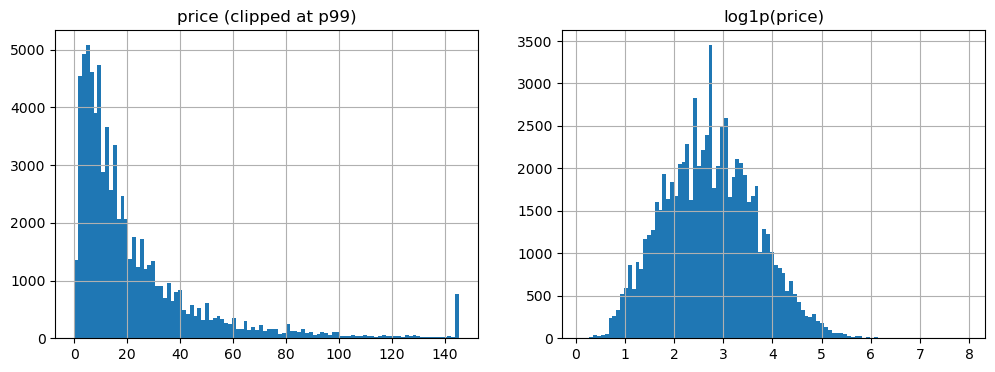

In [11]:
import numpy as np
import matplotlib.pyplot as plt

p = train["price"]
print(p.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99, .999]))
print("Zero/negative prices:", (p <= 0).sum())
print("Skew raw:", p.skew(), "| Skew log1p:", np.log1p(p).skew())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
p.clip(upper=p.quantile(0.99)).hist(bins=100, ax=ax[0]); 
ax[0].set_title("price (clipped at p99)")
np.log1p(p).hist(bins=100, ax=ax[1]); 
ax[1].set_title("log1p(price)")
plt.show()

In [12]:
dup_text_train = train.catalog_content.duplicated(keep=False)
print("Rows in train with duplicated catalog_content:", dup_text_train.sum())
print("Duplicated image_link (train):", train.image_link.duplicated().sum())

overlap = test.catalog_content.isin(set(train.catalog_content))
print("Test rows whose catalog_content appears exactly in train:", overlap.sum())

g = train[dup_text_train].groupby("catalog_content")["price"].agg(["count", "min", "max"])
g["ratio"] = g["max"] / g["min"]
print(g["ratio"].describe())

Rows in train with duplicated catalog_content: 193
Duplicated image_link (train): 2712
Test rows whose catalog_content appears exactly in train: 234
count    93.000000
mean      1.779968
std       1.927135
min       1.000000
25%       1.000000
50%       1.131280
75%       1.636198
max      16.102222
Name: ratio, dtype: float64


In [13]:
import sys
sys.path.append("..")
from src.metrics import smape

print("Sanity check:", round(smape([100], [120]), 2))  # should be 18.18

y = train.price.values
cands = {
    "mean": y.mean(),
    "median": np.median(y),
    "geo_mean": np.exp(np.log(y[y > 0]).mean()),
}
grid = np.linspace(np.percentile(y, 5), np.percentile(y, 95), 400)
best_c = grid[np.argmin([smape(y, np.full_like(y, c)) for c in grid])]
cands["best_constant"] = best_c
for k, v in cands.items():
    print(f"{k:14s} c={v:8.3f}  SMAPE={smape(y, np.full_like(y, v)):.2f}%")

Sanity check: 18.18
mean           c=  23.648  SMAPE=79.06%
median         c=  14.000  SMAPE=72.70%
geo_mean       c=  13.884  SMAPE=72.72%
best_constant  c=  14.376  SMAPE=72.69%


In [15]:
ID_COL, TEXT_COL, TARGET_COL, IMG_COL = "sample_id", "catalog_content", "price", "image_link"

print(train.dtypes)
print("train ID unique:", train[ID_COL].is_unique, "| test ID unique:", test[ID_COL].is_unique)
print("train/test ID overlap:", len(set(train[ID_COL]) & set(test[ID_COL])))

sample_test = pd.read_csv(DATASET / "sample_test.csv")
print("sample_test_out columns:", sample_out.columns.tolist(), "| rows:", len(sample_out))
print("IDs match sample_test:", set(sample_out[ID_COL]) == set(sample_test[ID_COL]))

for name, d in [("train", train), ("test", test)]:
    print(name, "missing links:", d[IMG_COL].isna().sum(), "| duplicate links:", d[IMG_COL].duplicated().sum())

sample_id            int64
catalog_content     object
image_link          object
price              float64
dtype: object
train ID unique: True | test ID unique: True
train/test ID overlap: 0
sample_test_out columns: ['sample_id', 'price'] | rows: 100
IDs match sample_test: True
train missing links: 0 | duplicate links: 2712
test missing links: 0 | duplicate links: 2778


                 train_null  test_null
catalog_content           0        0.0
image_link                0        0.0
price                     0        NaN
sample_id                 0        0.0

dup text (train): 100
dup text (test): 119
test texts also in train: 234

 count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
1%           1.320000
5%           2.440000
25%          6.795000
50%         14.000000
75%         28.625000
95%         75.711000
99%        145.250300
max       2796.000000
Name: price, dtype: float64
skew: 13.6 | skew after log1p: 0.2
zeros: 0 | negatives: 0


0         4.890
1        13.120
2         1.970
3        30.340
4        66.490
          ...  
74995    10.395
74996    35.920
74997    50.330
74998    15.275
74999    28.240
Name: price, Length: 75000, dtype: float64

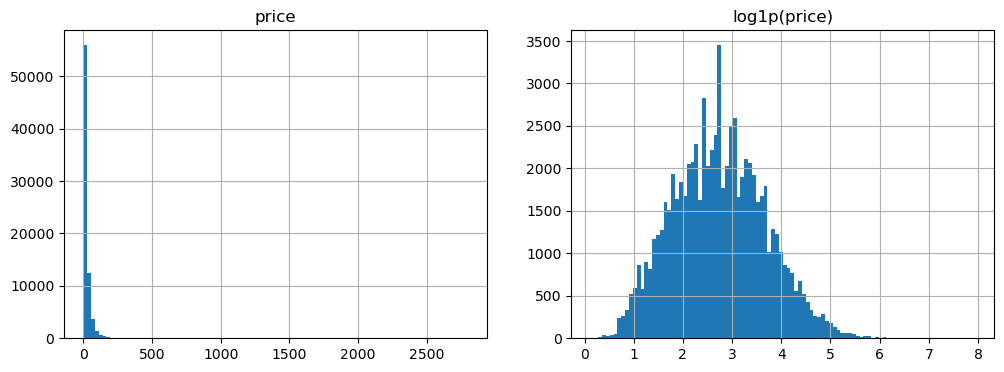

In [16]:
import matplotlib.pyplot as plt

print(pd.DataFrame({"train_null": train.isna().sum(), "test_null": test.isna().sum()}))
print("\ndup text (train):", train[TEXT_COL].duplicated().sum())
print("dup text (test):", test[TEXT_COL].duplicated().sum())
print("test texts also in train:", test[TEXT_COL].isin(set(train[TEXT_COL])).sum())

y = train[TARGET_COL]
print("\n", y.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))
print("skew:", round(y.skew(), 2), "| skew after log1p:", round(np.log1p(y).skew(), 2))
print("zeros:", (y == 0).sum(), "| negatives:", (y < 0).sum())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
y.hist(bins=100, ax=ax[0]); ax[0].set_title("price")
np.log1p(y).hist(bins=100, ax=ax[1]); ax[1].set_title("log1p(price)")
plt.savefig(ROOT / "reports" / "figures" / "price_dist.png", dpi=120, bbox_inches="tight")
p

In [17]:
def text_stats(s):
    s = s.fillna("").astype(str)
    return pd.DataFrame({
        "n_chars": s.str.len(),
        "n_words": s.str.split().str.len(),
        "n_digits": s.str.count(r"\d"),
    })

tr_stats, te_stats = text_stats(train[TEXT_COL]), text_stats(test[TEXT_COL])
print("TRAIN"); print(tr_stats.describe().T)
print("\nTEST");  print(te_stats.describe().T)
print("\nSpearman vs log price:")
print(pd.concat([tr_stats, np.log1p(y).rename("log_price")], axis=1).corr(method="spearman")["log_price"])

TRAIN
            count        mean         std   min    25%    50%     75%     max
n_chars   75000.0  908.886547  852.896151  32.0  251.0  643.0  1280.0  7894.0
n_words   75000.0  147.851693  137.068731   7.0   42.0  104.0   208.0  1333.0
n_digits  75000.0   14.533027    8.603863   0.0    8.0   13.0    19.0   262.0

TEST
            count        mean         std   min    25%    50%     75%      max
n_chars   75000.0  910.762947  857.030190  37.0  252.0  636.0  1288.0  11136.0
n_words   75000.0  148.145907  137.760572   7.0   42.0  103.0   210.0   1928.0
n_digits  75000.0   14.527320    8.512676   0.0    8.0   13.0    19.0    150.0

Spearman vs log price:
n_chars      0.258013
n_words      0.253662
n_digits     0.191001
log_price    1.000000
Name: log_price, dtype: float64
